In [ ]:
# https://gemini.google.com/app/382b654dbefb22e8


import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [75]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [76]:
# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import align_comp_to_port, evaluate_bbox

In [77]:

# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation(),
        "routing_metal": "met2",
        "dummy_devices": True,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}
nmos_kwargs = {
    "with_tie": False,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

pmos_kwargs = {
    "with_tie": False,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2", "met1"),
    "dummy_routes": True,
}

In [78]:



pdk = gf180
stdp_comp = Component(name="stdp_lvs")
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

# =========================================================================
# 1. INSTANTIATE ALL DEVICES MATCHING SPICE NETLIST
# =========================================================================

# --- PMOS TRANSISTORS ---
# XM1: W=0.22u, L=0.28u
xm1 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM2: W=0.22u, L=0.28u
xm2 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM7: W=0.22u, L=0.28u
xm7 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM8: W=0.22u, L=0.28u
xm8 = pmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM17: W=0.3u, L=4.6u
xm17 = pmos(pdk, width=0.5, length=4.6, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM16: W=10.2u, L=2.8u
xm16 = pmos(pdk, width=10.2, length=2.8, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- NMOS TRANSISTORS ---
# XM3: W=0.22u, L=0.28u
xm3 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM4: W=0.22u, L=0.28u
xm4 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM9: W=0.22u, L=0.28u
xm9 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM12: W=0.22u, L=0.28u
xm12 = nmos(pdk, width=0.5, length=0.28, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XMCM_1: W=0.61u, L=2.8u
xmcm_1 = nmos(pdk, width=0.61, length=2.8, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

# --- LONG-CHANNEL BIAS CHAIN (XMCM_5 to XMCM_9): W=0.5u, L=10u ---
xmcm_chain = [
    nmos(pdk, width=0.5, length=10.0, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    for _ in range(5)
]

# --- MIM CAPACITORS ---
# Cpot: 5x5um, m=2 (2 rows, 1 col)
cpot = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cdep: 5x5um, m=2 (2 rows, 1 col)
cdep = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cw: 5x5um, m=10 (2 rows, 5 cols)
cw = mimcap_array(pdk, size=(5, 5), rows=2, columns=5)

# =========================================================================
# 2. PLACEMENT & FLOORPLANNING
# =========================================================================

# Add components to subcircuit
#top row
xm1_ref = stdp_comp << xm1
xm2_ref = stdp_comp << xm2
xm7_ref = stdp_comp << xm7
xm8_ref = stdp_comp << xm8
xm17_ref = stdp_comp << xm17
xm16_ref = stdp_comp << xm16


# second row
xm3_ref = stdp_comp << xm3
xm4_ref = stdp_comp << xm4
xm9_ref = stdp_comp << xm9
xm12_ref = stdp_comp << xm12
xmcm_1_ref = stdp_comp << xmcm_1
chain_refs = [stdp_comp << dev for dev in xmcm_chain]

cpot_ref = stdp_comp << cpot
cdep_ref = stdp_comp << cdep
cw_ref = stdp_comp << cw

xm1_ref.name = "xm1" 
xm2_ref.name = "xm2" 
xm7_ref.name = "xm7" 
xm8_ref.name = "xm8" 
xm17_ref.name = "xm17" 
xm16_ref.name = "xm16" 
xm3_ref.name = "xm3"
xm4_ref.name = "xm4"
xm9_ref.name = "xm9"
xm12_ref.name = "xm12"
cpot_ref.name = "cpot" 
cdep_ref.name = "cdep" 
cw_ref.name = "cw" 

# --- TOP ROW: PMOS Array ---
xm1_xy = evaluate_bbox(xm1)
xm2_xy = evaluate_bbox(xm2)
xm7_xy = evaluate_bbox(xm8)
xm8_xy = evaluate_bbox(xm8)
xm17_xy = evaluate_bbox(xm17)
xm16_xy = evaluate_bbox(xm16)
cpot_xy = evaluate_bbox(cpot)
xm1_ref.move((0 + xm1_xy[0]/2, 25))
xm2_ref.move((xm1_ref.xmax + xm2_xy[0]/2 + spacing, 25))
xm7_ref.move((xm2_ref.xmax + xm7_xy[0]/2 + spacing, 25))
xm8_ref.move((xm7_ref.xmax + xm8_xy[0]/2 + spacing, 25))
xm17_ref.move((xm8_ref.xmax + xm17_xy[0]/2 + spacing, 25))
xm16_ref.move((xm17_ref.xmax + xm16_xy[0]/2 + spacing, 25))


# --- MIDDLE ROW: Standard NMOS Array ---
xm3_xy = evaluate_bbox(xm3)
xm4_xy = evaluate_bbox(xm4)
xm9_xy = evaluate_bbox(xm9)
xm12_xy = evaluate_bbox(xm12)
xmcm_1_xy = evaluate_bbox(xmcm_1)
cdep_xy = evaluate_bbox(cdep)

xm3_ref.move((0 + xm3_xy[0]/2, 10))
xm4_ref.move((xm3_ref.xmax + xm4_xy[0]/2 + spacing, 10))
xm9_ref.move((xm4_ref.xmax + xm9_xy[0]/2 +spacing, 10))
xm12_ref.move((xm9_ref.xmax + xm12_xy[0]/2 + spacing, 10))
xmcm_1_ref.move((xm12_ref.xmax + xmcm_1_xy[0]/2 + spacing, 10))


# --- BOTTOM ROW: Long-Channel Bias Chain (Series connected) ---
xy_first = evaluate_bbox(chain_refs[0])
curr_x = xy_first[0]/2
for ref in chain_refs:
    ref.move((curr_x , 0))
    xy_next = evaluate_bbox(ref)
    curr_x = ref.xmax + xy_next[0]/2 + spacing



# --- MOVING CAPACITORS: 
cw_xy = evaluate_bbox(cw)
cpot_ref.move((xm16_ref.xmax + cpot_xy[0]/2 + spacing * 2, 25))
cdep_ref.move((xm16_ref.xmax + cdep_xy[0]/2 + spacing * 2, 10))
cw_ref.move((xm16_ref.xmax + cw_xy[0]/2, 20))




ComponentReference (parent Component "Unnamed_5ddcf88d", ports ['row0_col0_array_row0_col0_bottom_layer_W', 'row0_col0_array_row0_col0_bottom_via_W', 'row0_col0_array_row0_col0_bottom_met_W', 'row0_col0_array_row0_col0_top_met_W', 'row0_col0_array_row0_col1_bottom_layer_W', 'row0_col0_array_row0_col1_bottom_via_W', 'row0_col0_array_row0_col1_bottom_met_W', 'row0_col0_array_row0_col1_top_met_W', 'row0_col0_array_row0_col2_bottom_layer_W', 'row0_col0_array_row0_col2_bottom_via_W', 'row0_col0_array_row0_col2_bottom_met_W', 'row0_col0_array_row0_col2_top_met_W', 'row0_col0_array_row0_col3_bottom_layer_W', 'row0_col0_array_row0_col3_bottom_via_W', 'row0_col0_array_row0_col3_bottom_met_W', 'row0_col0_array_row0_col3_top_met_W', 'row0_col1_array_row0_col0_bottom_layer_W', 'row0_col1_array_row0_col0_bottom_via_W', 'row0_col1_array_row0_col0_bottom_met_W', 'row0_col1_array_row0_col0_top_met_W', 'row0_col1_array_row0_col1_bottom_layer_W', 'row0_col1_array_row0_col1_bottom_via_W', 'row0_col1_arra

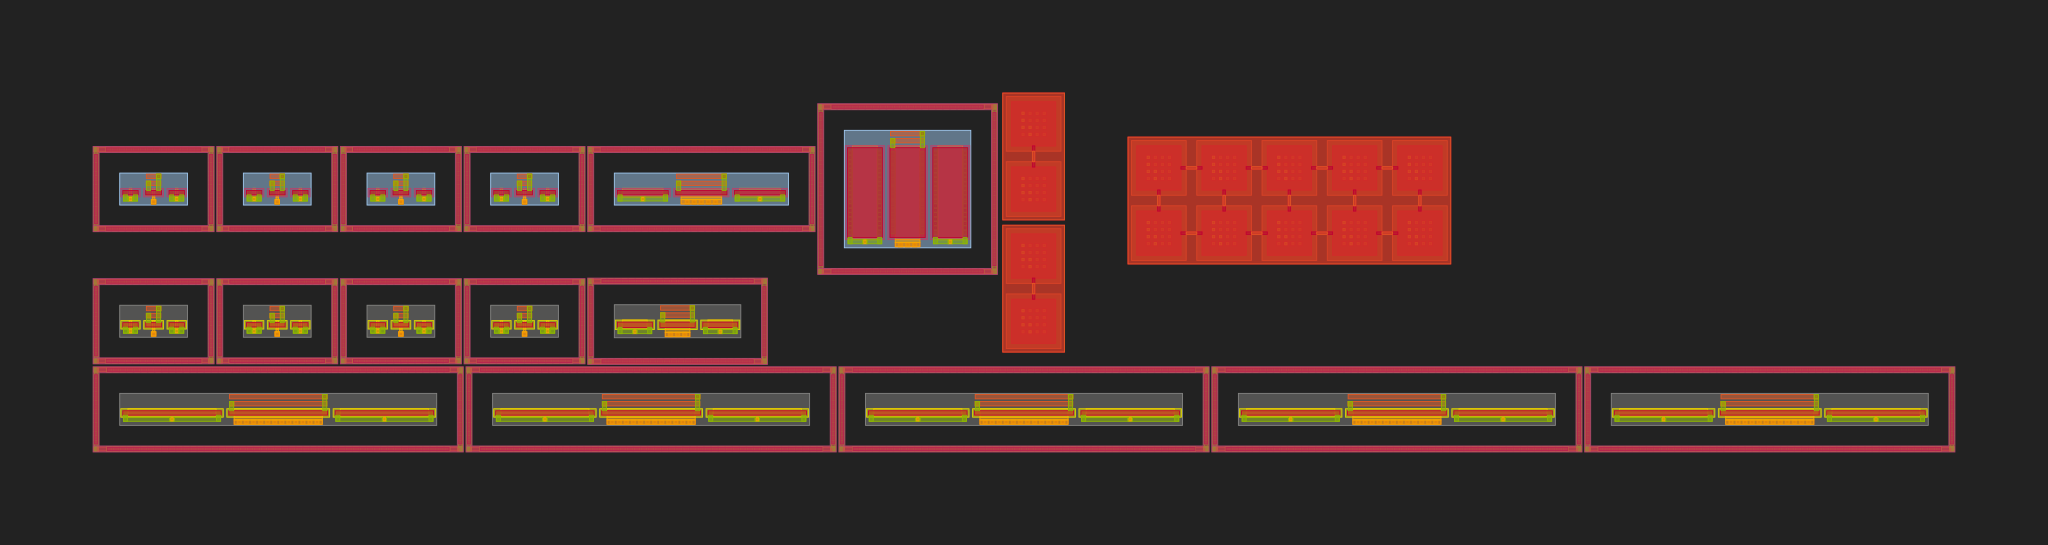

In [79]:
display_component(stdp_comp, scale = 1,path=".")

In [80]:
cpot_ref.ports

{'row0_col0_array_row0_col0_bottom_layer_W': {'name': 'row0_col0_array_row0_col0_bottom_layer_W', 'width': 0.5, 'center': [105.19, 23.8], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_bottom_via_W': {'name': 'row0_col0_array_row0_col0_bottom_via_W', 'width': 0.26, 'center': [105.31, 23.8], 'orientation': 180.0, 'layer': [38, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_bottom_met_W': {'name': 'row0_col0_array_row0_col0_bottom_met_W', 'width': 0.5, 'center': [105.19, 23.8], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col0_top_met_W': {'name': 'row0_col0_array_row0_col0_top_met_W', 'width': 0.5, 'center': [105.19, 23.8], 'orientation': 180.0, 'layer': [42, 0], 'port_type': 'electrical'},
 'row0_col0_array_row0_col1_bottom_layer_W': {'name': 'row0_col0_array_row0_col1_bottom_layer_W', 'width': 0.5, 'center': [105.99, 23.8], 'orientation': 180.0, 'layer': [36, 0], 'port_type': 'e

In [81]:
# =========================================================================
# 3. ROUTING & NET CONNECTIONS
# =========================================================================

# --- 1. Internal Series Links (Straight & L-Routes) ---

# Net1: XM1 Drain to XM2 Source
stdp_comp << straight_route(
    pdk, 
    xm1_ref.ports["multiplier_0_source_E"], 
    xm2_ref.ports["multiplier_0_drain_W"]
)

# Net2: XM3 Source to XM4 Drain
stdp_comp << straight_route(
    pdk, 
    xm3_ref.ports["multiplier_0_source_E"], 
    xm4_ref.ports["multiplier_0_drain_W"]
)

# Net3: XM7 Drain to XMCM_1 Drain
stdp_comp << straight_route(
    pdk, 
    xm7_ref.ports["multiplier_0_drain_S"], 
    xmcm_1_ref.ports["multiplier_0_drain_N"]
)

# Net4: XM7 Gate to XM8 Drain
stdp_comp << straight_route(
    pdk, 
    xm7_ref.ports["multiplier_0_gate_E"], 
    xm8_ref.ports["multiplier_0_drain_W"]
)

# Net5: XM9 Drain/Gate short to XM12 Drain and XM16 Drain
stdp_comp << straight_route(
    pdk, 
    xm9_ref.ports["multiplier_0_gate_E"], 
    xm9_ref.ports["multiplier_0_drain_E"]
)
stdp_comp << straight_route(
    pdk, 
    xm9_ref.ports["multiplier_0_drain_E"], 
    xm12_ref.ports["multiplier_0_drain_W"]
)

# --- 2. Long-Channel Series Bias Chain (XMCM_5 to XMCM_9) ---
for i in range(len(chain_refs) - 1):
    stdp_comp << straight_route(
        pdk,
        chain_refs[i].ports["multiplier_0_source_E"],
        chain_refs[i + 1].ports["multiplier_0_drain_W"],
    )

# Common Gate for XMCM Bias Chain (vb_itd)
for i in range(len(chain_refs) - 1):
    stdp_comp << straight_route(
        pdk,
        chain_refs[i].ports["multiplier_0_gate_E"],
        chain_refs[i + 1].ports["multiplier_0_gate_W"],
    )


In [82]:
def get_mimcap_ports(cap_ref, direction="W"):
    """
    Safely retrieves the main top and bottom plate ports for a MIM cap reference.
    direction: 'N', 'S', 'E', or 'W'
    """
    bottom_port = None
    top_port = None
    
    # 1. Try to find aggregated array-level ports
    for name, port in cap_ref.ports.items():
        if name.endswith(f"bottom_met_{direction}") and not "array_" in name:
            bottom_port = port
        elif name.endswith(f"top_met_{direction}") and not "array_" in name:
            top_port = port
            
    # 2. Fallback: Take the first row/col array port matching the direction
    if not bottom_port:
        bottom_keys = [k for k in cap_ref.ports.keys() if f"bottom_met_{direction}" in k]
        if bottom_keys:
            bottom_port = cap_ref.ports[bottom_keys[0]]
            
    if not top_port:
        top_keys = [k for k in cap_ref.ports.keys() if f"top_met_{direction}" in k]
        if top_keys:
            top_port = cap_ref.ports[top_keys[0]]

    return bottom_port, top_port


In [ ]:
#https://gemini.google.com/app/bb77a9af0bf54161

# --- Extract Capacitor Ports ---
cpot_bottom, cpot_top = get_mimcap_ports(cpot_ref, direction="W")
cdep_bottom, cdep_top = get_mimcap_ports(cdep_ref, direction="W")
cw_bottom, cw_top = get_mimcap_ports(cw_ref, direction="W")

# -------------------------------------------------------------------------
# Node 1: Vpot (XM1 Gate, XM8 Source, XM17 Drain, CPOT Bottom Plate)
# -------------------------------------------------------------------------
# XM17 Drain -> CPOT Bottom Plate
stdp_comp << straight_route(
    pdk,
    xm17_ref.ports["multiplier_0_drain_E"],
    cpot_bottom
)

# XM8 Source -> CPOT Bottom Plate
stdp_comp << straight_route(
    pdk,
    xm8_ref.ports["multiplier_0_source_E"],
    cpot_bottom
)

# CPOT Top Plate -> AVDD Power Rail
stdp_comp << straight_route(
    pdk,
    cpot_top,
    xm16_ref.ports["multiplier_0_source_E"]  # Connects top plate to AVDD net
)

# -------------------------------------------------------------------------
# Node 2: Vdep (XM4 Gate, XM12 Source, CDEP Top Plate, XMCM_5 Drain)
# -------------------------------------------------------------------------
# XM12 Source -> CDEP Top Plate
stdp_comp << straight_route(
    pdk,
    xm12_ref.ports["multiplier_0_source_E"],
    cdep_top
)

# CDEP Bottom Plate -> AVSS Ground Rail
stdp_comp << straight_route(
    pdk,
    cdep_bottom,
    xmcm_1_ref.ports["multiplier_0_source_E"] # Connects bottom plate to AVSS net
)

# -------------------------------------------------------------------------
# Node 3: Vw (XM2 Drain, XM3 Drain, CW Top Plate)
# -------------------------------------------------------------------------
# XM2 Drain -> CW Top Plate
stdp_comp << straight_route(
    pdk,
    xm2_ref.ports["multiplier_0_drain_E"],
    cw_top,
    width=2.5
)

# XM3 Drain -> CW Top Plate
stdp_comp << straight_route(
    pdk,
    xm3_ref.ports["multiplier_0_drain_E"],
    cw_top,
    width=3.5
)

# CW Bottom Plate -> AVSS Ground Rail
stdp_comp << straight_route(
    pdk,
    cw_bottom,
    chain_refs[-1].ports["multiplier_0_source_E"] # Bottom plate to AVSS
)

ComponentReference (parent Component "straight_route_62e79bf1$1", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

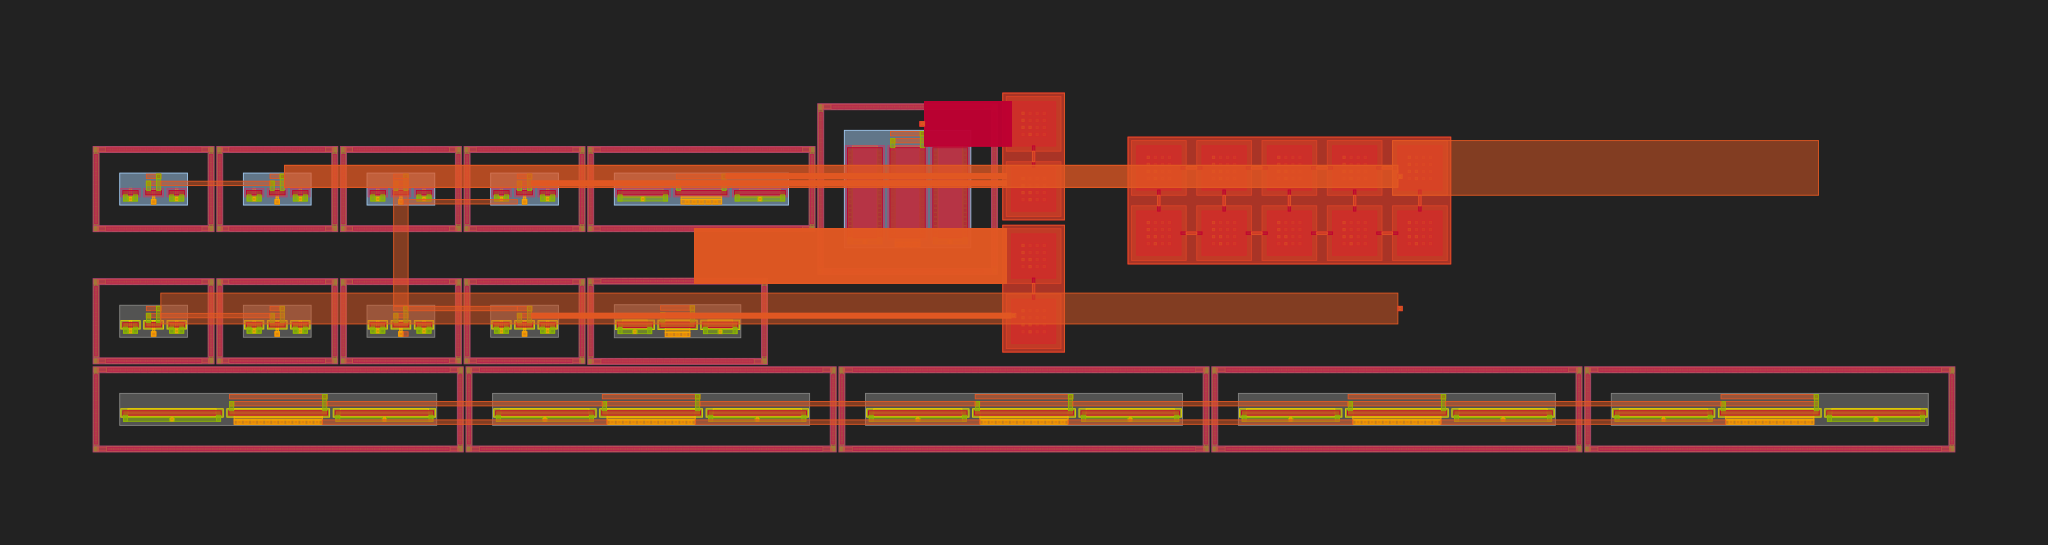

In [97]:
display_component(stdp_comp, scale = 1,path=".")

In [100]:
evaluate_bbox(stdp_comp)

(211.1, 40.735)